# 01 - Preparación del Dataset en PyTorch

## 1. Imports y configuración

In [1]:
from pathlib import Path
import os
import sys
import random
import json
import zipfile
import subprocess
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prod.detection_dataset import (
    CarDamageDetectionDataset,
    ComposeDetection,
    RandomHorizontalFlipDetection,
    ToTensorDetection,
    collate_fn,
)


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    DATA_DIR = Path("/content/data")
else:
    DATA_DIR = Path("../data")

RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Entorno Colab:", IS_COLAB)
print("DATA_DIR:", DATA_DIR)


Entorno Colab: False
DATA_DIR: ../data


## 1.b Instalación opcional de dependencias

Instala dependencias si el notebook corre en Google Colab.

In [3]:
if IS_COLAB:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "pandas",
        "numpy",
        "matplotlib",
        "pillow",
        "torch",
        "torchvision",
        "tqdm",
        "jupyter",
        "kaggle",
        "gdown",
    ])
else:
    print("Instalación opcional omitida: usá tu entorno local con requirements.txt")


Instalación opcional omitida: usá tu entorno local con requirements.txt


## 2. Descarga / ubicación del dataset

Detecta el dataset local y, si no existe, lo descarga y extrae automáticamente.

In [4]:
CARDD_VIEW_URL = "https://drive.google.com/file/d/1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx/view"
CARDD_FILE_ID = "1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx"
ZIP_PATH = DATA_DIR / "CarDD_release.zip"
EXTRACT_DIR = DATA_DIR

def ensure_gdown():
    try:
        import gdown
        return gdown
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
        import gdown
        return gdown


def download_cardd_zip(file_id=CARDD_FILE_ID, zip_path=ZIP_PATH):
    if zip_path.exists() and zipfile.is_zipfile(zip_path):
        print(f"ZIP válido ya descargado en: {zip_path}")
        return zip_path

    if zip_path.exists() and not zipfile.is_zipfile(zip_path):
        print("El archivo descargado existente no es un ZIP válido. Se volverá a descargar.")
        zip_path.unlink()

    print("Descargando CarDD con gdown desde Google Drive...")
    gdown = ensure_gdown()
    gdown.download(id=file_id, output=str(zip_path), quiet=False)

    if not zipfile.is_zipfile(zip_path):
        raise zipfile.BadZipFile("La descarga no produjo un archivo ZIP válido.")

    print(f"Descarga completada: {zip_path}")
    return zip_path


def extract_cardd_zip(zip_path=ZIP_PATH, extract_dir=EXTRACT_DIR):
    if not zip_path.exists():
        raise FileNotFoundError(f"No existe el ZIP en {zip_path}")

    if not zipfile.is_zipfile(zip_path):
        raise zipfile.BadZipFile(f"{zip_path} no es un ZIP válido")

    print(f"Extrayendo {zip_path} en {extract_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extracción completada.")


def find_dataset_root():
    dataset_candidates = [
        RAW_DIR / "CarDD",
        DATA_DIR / "CarDD",
        DATA_DIR / "CarDD_release",
        DATA_DIR / "CarDD_release" / "CarDD_COCO",
        DATA_DIR / "CarDD" / "CarDD_COCO",
    ]
    return next((path for path in dataset_candidates if path.exists()), None), dataset_candidates

dataset_root, dataset_candidates = find_dataset_root()

if dataset_root is None:
    print("Dataset no encontrado. Intentando descargar y extraer automáticamente...")
    download_cardd_zip()
    extract_cardd_zip()
    dataset_root, dataset_candidates = find_dataset_root()

if dataset_root is None:
    raise FileNotFoundError(
        "No se encontró el dataset incluso después de intentar descargarlo automáticamente.\n"
        + "Rutas verificadas:\n"
        + "\n".join(str(path) for path in dataset_candidates)
    )

print("Dataset encontrado en:", dataset_root)


Dataset encontrado en: ../data/CarDD_release


## 3. Exploración de estructura de carpetas

Muestra la estructura de la parte COCO del dataset y cuenta solo sus imágenes.

In [5]:
if (dataset_root / "CarDD_COCO").exists():
    coco_root = dataset_root / "CarDD_COCO"
else:
    coco_root = dataset_root

for path in sorted(coco_root.iterdir()):
    print(path)


../data/CarDD_release/CarDD_COCO/annotations
../data/CarDD_release/CarDD_COCO/test2017
../data/CarDD_release/CarDD_COCO/train2017
../data/CarDD_release/CarDD_COCO/val2017


In [6]:
image_paths = [
    path for path in coco_root.rglob("*")
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Cantidad de imágenes COCO encontradas:", len(image_paths))


Cantidad de imágenes COCO encontradas: 4000


## 4. Preparación de anotaciones COCO para detección

Convierte los JSON COCO en registros por imagen con boxes, labels y split.

In [7]:
if (dataset_root / "CarDD_COCO").exists():
    coco_root = dataset_root / "CarDD_COCO"
else:
    coco_root = dataset_root

annotation_dir = coco_root / "annotations"
annotation_files = {
    "train": annotation_dir / "instances_train2017.json",
    "val": annotation_dir / "instances_val2017.json",
    "test": annotation_dir / "instances_test2017.json",
}

missing_files = [str(path) for path in annotation_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Faltan archivos de anotaciones COCO:\n" + "\n".join(missing_files)
    )

categories = None
category_id_to_name = {}
class_to_idx = {"background": 0}
idx_to_class = {0: "background"}
split_records = {}
csv_rows = []
all_box_labels = []
skipped_images = defaultdict(int)

for split, annotation_path in annotation_files.items():
    data = json.loads(annotation_path.read_text(encoding="utf-8"))

    if categories is None:
        categories = sorted(data["categories"], key=lambda item: item["id"])
        category_id_to_name = {category["id"]: category["name"] for category in categories}
        for idx, category in enumerate(categories, start=1):
            class_to_idx[category["name"]] = idx
            idx_to_class[idx] = category["name"]

    images_by_id = {image["id"]: image for image in data["images"]}
    annotations_by_image = defaultdict(list)

    for ann in data["annotations"]:
        annotations_by_image[ann["image_id"]].append(ann)

    records = []


# Para cada imagen del dataset, buscar su archivo en disco. 
# Si existe, preparar listas vacías para guardar sus bounding boxes, labels, áreas, flags de crowd y nombres de clases. 
    for image_id, image_info in images_by_id.items():
        filename = image_info.get("file_name")
        image_path = coco_root / f"{split}2017" / filename

        if not image_path.exists():
            continue

        boxes = []
        labels = []
        areas = []
        iscrowd = []
        label_names = []

        # Para cada anotación asociada a la imagen, pasar de COCO/XYWH a Pascal VOC/XYXY
        
        for ann in annotations_by_image.get(image_id, []):
            x, y, width, height = ann["bbox"]
            xmin = float(x)
            ymin = float(y)
            xmax = float(x + width)
            ymax = float(y + height)

            if xmax <= xmin or ymax <= ymin:
                continue

            category_name = category_id_to_name[ann["category_id"]]
            label_idx = class_to_idx[category_name]

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label_idx)
            areas.append(float(ann.get("area", width * height)))
            iscrowd.append(int(ann.get("iscrowd", 0)))
            label_names.append(category_name)
            all_box_labels.append(category_name)

        if not boxes:
            skipped_images[split] += 1
            continue

        records.append({
            "image_path": str(image_path.relative_to(DATA_DIR)),
            "image_id": int(image_id),
            "boxes": boxes,
            "labels": labels,
            "label_names": label_names,
            "area": areas,
            "iscrowd": iscrowd,
            "split": split,
            "width": int(image_info.get("width", 0)),
            "height": int(image_info.get("height", 0)),
        })

        unique_label_names = sorted(set(label_names))
        image_label = unique_label_names[0] if len(unique_label_names) == 1 else "multiple_damage"
        csv_rows.append({
            "image_path": str(image_path.relative_to(DATA_DIR)),
            "label": image_label,
            "split": split,
        })

    split_records[split] = records

records = split_records["train"] + split_records["val"] + split_records["test"]
detection_df = pd.DataFrame([
    {
        "image_path": record["image_path"],
        "image_id": record["image_id"],
        "num_boxes": len(record["boxes"]),
        "label_names": ", ".join(sorted(set(record["label_names"]))),
        "split": record["split"],
    }
    for record in records
])

csv_manifest_df = pd.DataFrame(csv_rows).drop_duplicates(subset=["image_path"])

if detection_df.empty:
    raise ValueError("No se pudieron construir registros válidos de detección desde COCO.")

summary_text = (
    f"{detection_df.head()}\n\n"
    f"Columnas disponibles: {detection_df.columns.tolist()}\n"
    f"Total de imágenes con boxes válidas: {len(detection_df)}\n\n"
    f"Distribución por split oficial:\n{detection_df['split'].value_counts()}\n\n"
    f"Imágenes omitidas por split (sin boxes válidas):\n{dict(skipped_images)}\n\n"
    f"Mapeo de clases:\n{class_to_idx}"
)
print(summary_text)


                                      image_path  image_id  num_boxes  \
0  CarDD_release/CarDD_COCO/train2017/000001.jpg         1          2   
1  CarDD_release/CarDD_COCO/train2017/000002.jpg         2          1   
2  CarDD_release/CarDD_COCO/train2017/000003.jpg         3          1   
3  CarDD_release/CarDD_COCO/train2017/000004.jpg         4          1   
4  CarDD_release/CarDD_COCO/train2017/000005.jpg         5          1   

          label_names  split  
0  scratch, tire flat  train  
1           tire flat  train  
2           tire flat  train  
3           tire flat  train  
4           tire flat  train  

Columnas disponibles: ['image_path', 'image_id', 'num_boxes', 'label_names', 'split']
Total de imágenes con boxes válidas: 4000

Distribución por split oficial:
split
train    2816
val       810
test      374
Name: count, dtype: int64

Imágenes omitidas por split (sin boxes válidas):
{}

Mapeo de clases:
{'background': 0, 'dent': 1, 'scratch': 2, 'crack': 3, 'glass shatte

## Distribución de clases

Resume la distribución de clases usando las anotaciones de detección.

In [8]:
box_class_counts = pd.Series(all_box_labels).value_counts().sort_values(ascending=False)
box_class_counts


scratch          3595
dent             2543
crack             898
lamp broken       704
glass shatter     681
tire flat         319
Name: count, dtype: int64

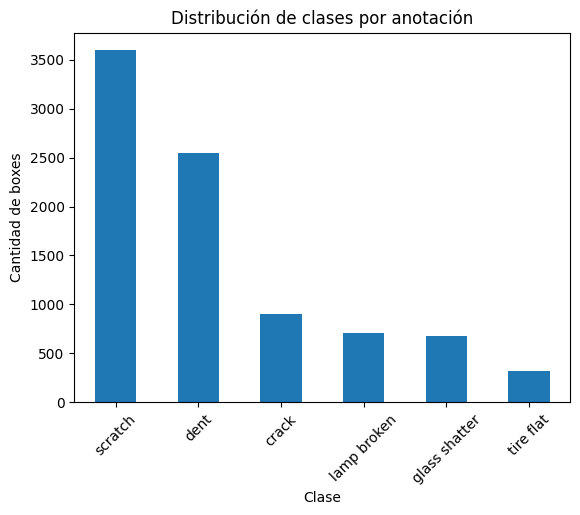

In [9]:
box_class_counts.plot(kind="bar")
plt.title("Distribución de clases por anotación")
plt.xlabel("Clase")
plt.ylabel("Cantidad de boxes")
plt.xticks(rotation=45)
plt.show()


## 5. Uso de splits oficiales train / val / test

Se reutilizan los splits oficiales y se separan en train, val y test para detección.

In [19]:
train_records = split_records["train"]
val_records = split_records["val"]
test_records = split_records["test"]

print("Train imágenes:", len(train_records))
print("Val imágenes:", len(val_records))
print("Test imágenes:", len(test_records))
print("Train boxes:", sum(len(record["boxes"]) for record in train_records))
print("Val boxes:", sum(len(record["boxes"]) for record in val_records))
print("Test boxes:", sum(len(record["boxes"]) for record in test_records))


Train imágenes: 2816
Val imágenes: 810
Test imágenes: 374
Train boxes: 6211
Val boxes: 1744
Test boxes: 785


In [20]:
def box_count_table(records):
    counts = defaultdict(int)
    for record in records:
        for label_name in record["label_names"]:
            counts[label_name] += 1
    return pd.Series(counts)

dist_table = pd.DataFrame({
    "total": box_count_table(records),
    "train": box_count_table(train_records),
    "val": box_count_table(val_records),
    "test": box_count_table(test_records),
}).fillna(0).astype(int).sort_index()

dist_table


,total,train,val,test
crack,898,651,177,70
dent,2543,1806,501,236
glass shatter,681,475,135,71
lamp broken,704,494,141,69
scratch,3595,2560,728,307
tire flat,319,225,62,32


## 7. Definición de Transformaciones y Dataset


In [21]:
# La implementacion reutilizable vive en prod/detection_dataset.py.
print("Usando CarDamageDetectionDataset desde prod/detection_dataset.py")


## 8. Creación de las transoformaciones a aplicar para entrenamiento y para evaluación

Convierte imágenes a tensor y aplica augmentations que preservan las boxes.

In [22]:
train_transform = ComposeDetection([
    ToTensorDetection(),
    RandomHorizontalFlipDetection(p=0.5),
])

eval_transform = ComposeDetection([
    ToTensorDetection(),
])


## 9. DataLoaders

Crea los DataLoaders de detección con `collate_fn` para imágenes y targets variables.

In [ ]:
MODEL_NAME = "fasterrcnn"
USE_FIXED_IMAGE_SIZE = False
IMAGE_SIZE = None
BATCH_SIZE = 2

train_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="train",
    transform=train_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

val_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="val",
    transform=eval_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

test_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="test",
    transform=eval_transform,
    model_name=MODEL_NAME,
    resize=USE_FIXED_IMAGE_SIZE,
    image_size=IMAGE_SIZE,
)

class_to_idx = train_dataset.class_to_idx
idx_to_class = train_dataset.idx_to_class

num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)


## 10. Visualización de augmentations

Muestra imágenes de entrenamiento con bounding boxes antes y después de las transformaciones.

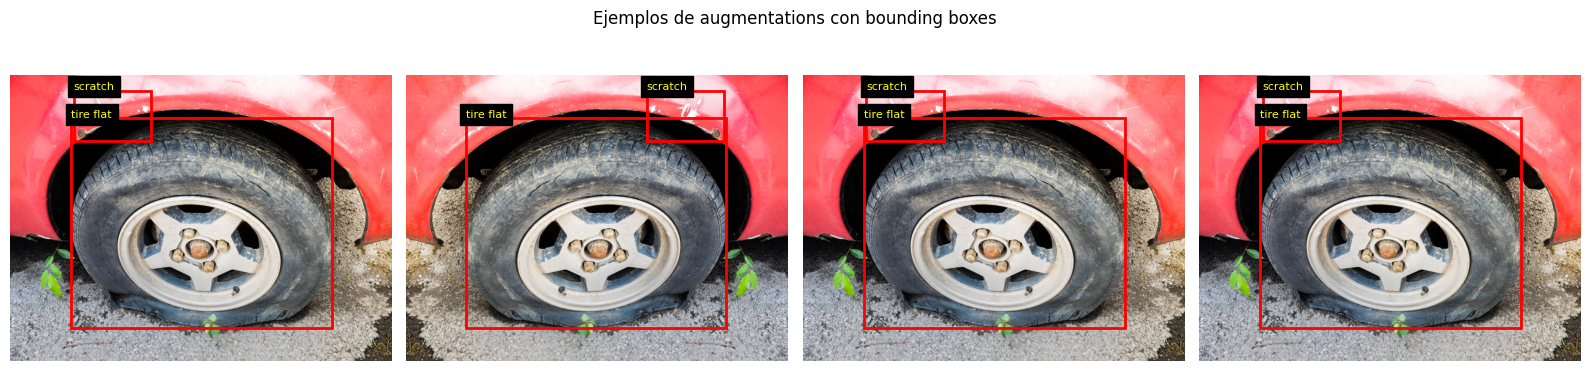

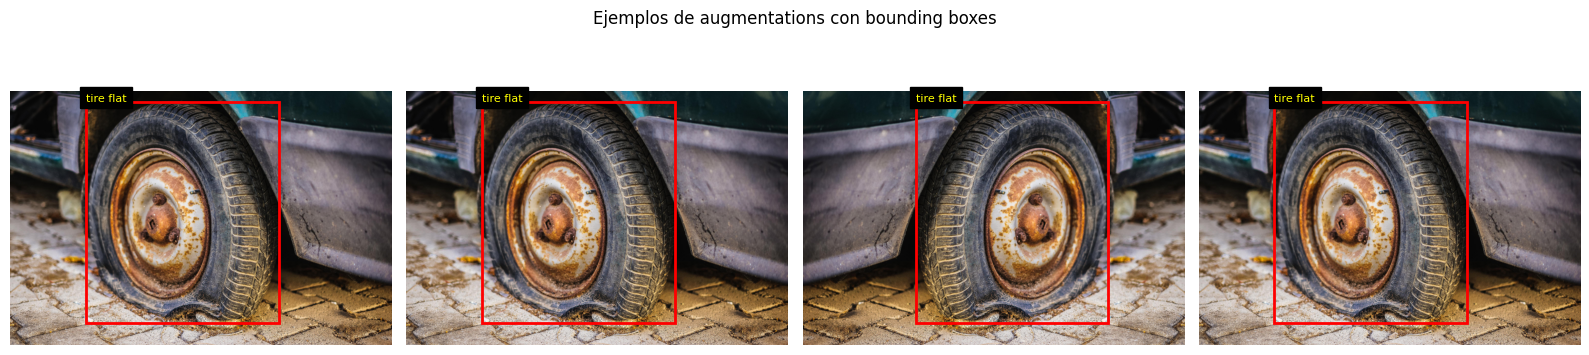

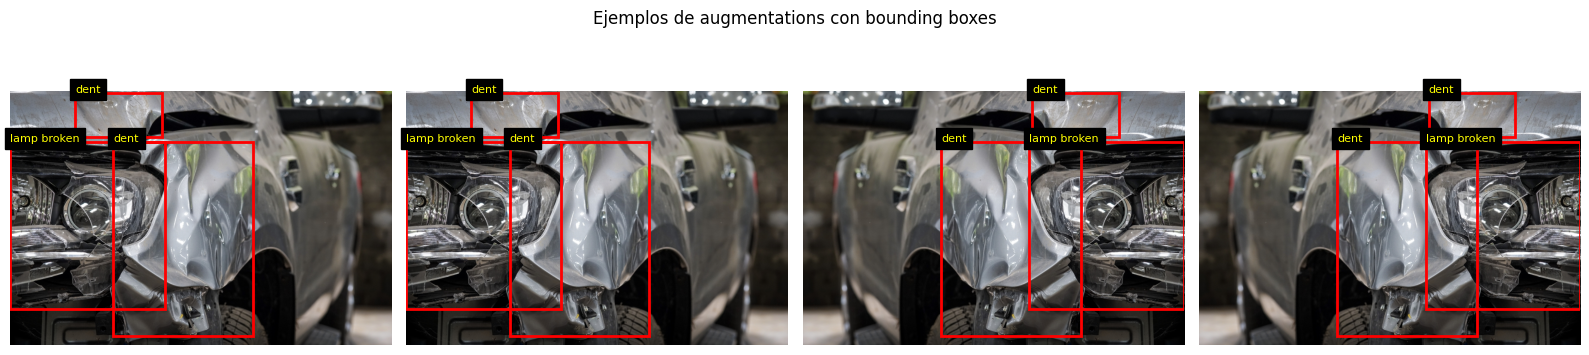

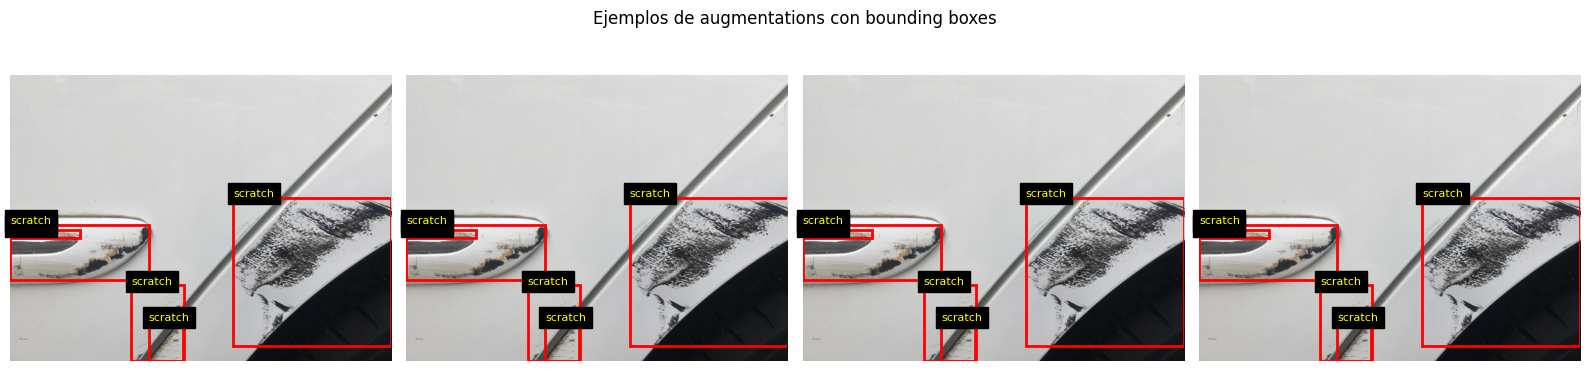

In [24]:
def draw_boxes(ax, image_tensor, target, idx_to_class, title=None):
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.axis("off")

    for box, label in zip(target["boxes"], target["labels"]):
        xmin, ymin, xmax, ymax = box.tolist()
        width = xmax - xmin
        height = ymax - ymin
        rect = Rectangle((xmin, ymin), width, height, fill=False, edgecolor="red", linewidth=2)
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 2, 0), idx_to_class[int(label.item())], color="yellow", fontsize=8, backgroundcolor="black")

    if title:
        ax.set_title(title)


def show_augmentations(dataset, index, n=4):
    if len(dataset) == 0:
        print("El dataset está vacío.")
        return

    index = min(index, len(dataset) - 1)
    record = dataset.records[index]
    image = Image.open(dataset.data_dir / record["image_path"]).convert("RGB")
    base_target = {
        "boxes": torch.tensor(record["boxes"], dtype=torch.float32),
        "labels": torch.tensor(record["labels"], dtype=torch.int64),
        "image_id": torch.tensor([record["image_id"]], dtype=torch.int64),
        "area": torch.tensor(record["area"], dtype=torch.float32),
        "iscrowd": torch.tensor(record["iscrowd"], dtype=torch.int64),
    }

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for axis in axes:
        transformed_image, transformed_target = train_transform(
            image.copy(),
            {
                "boxes": base_target["boxes"].clone(),
                "labels": base_target["labels"].clone(),
                "image_id": base_target["image_id"].clone(),
                "area": base_target["area"].clone(),
                "iscrowd": base_target["iscrowd"].clone(),
            },
        )
        draw_boxes(axis, transformed_image, transformed_target, idx_to_class)

    plt.suptitle("Ejemplos de augmentations con bounding boxes")
    plt.tight_layout()
    plt.show()

candidate_indices = [0, 10, 20, 30]
valid_indices = [idx for idx in candidate_indices if idx < len(train_dataset)]

for idx in valid_indices:
    show_augmentations(train_dataset, index=idx, n=4)

if not valid_indices:
    print("No hay suficientes imágenes para mostrar augmentations.")


## 11. Verificación final de batches

Verifica batch sizes, shapes y visualización final con bounding boxes.

In [17]:
images, targets = next(iter(train_loader))

print("Cantidad de imágenes en el batch:", len(images))
print("Cantidad de targets en el batch:", len(targets))
print("Shape de la primera imagen:", images[0].shape)
print("Shape de boxes de la primera muestra:", targets[0]["boxes"].shape)
print("Valor mínimo de la primera imagen:", images[0].min().item())
print("Valor máximo de la primera imagen:", images[0].max().item())


Cantidad de imágenes en el batch: 2
Cantidad de targets en el batch: 2
Shape de la primera imagen: torch.Size([3, 667, 1000])
Shape de boxes de la primera muestra: torch.Size([1, 4])
Valor mínimo de la primera imagen: 0.0
Valor máximo de la primera imagen: 1.0


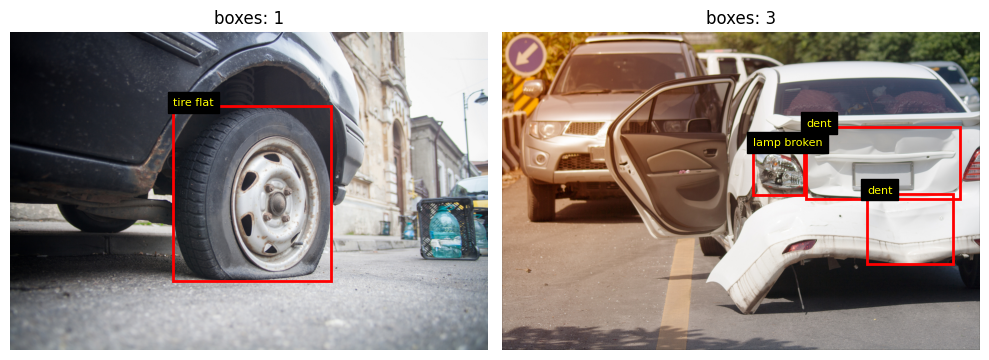

In [25]:
def show_batch(images, targets, idx_to_class, n=4):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    for i in range(n):
        draw_boxes(axes[i], images[i], targets[i], idx_to_class, title=f"boxes: {targets[i]['boxes'].shape[0]}")

    plt.tight_layout()
    plt.show()

show_batch(images, targets, idx_to_class, n=4)
